# Validation & final report

Does the disease-association result hold up when the analysis choices are varied, and does it
collapse when it should? Six checks, all consuming the persisted differential-abundance artifacts
and the same cohort inputs the earlier steps used — nothing here re-reads the raw counts CSV. The
logic lives in `src/validation.py`; this notebook runs it once end to end and writes
`reports/validation_{null,depth_sensitivity,transform_sensitivity,prevalence_sensitivity}.csv`,
`reports/literature_crosscheck.csv`, `reports/final_report.md` and the `reports/figures/phase6_*.png`
figures.

1. **Label-shuffling null** — permute case/control within each (project, category), re-run the
   meta-analysis and the pooled test. A working pipeline collapses to ~zero FDR hits.
2. **Depth-threshold sensitivity** — rebuild the within-study cohort at 5k / 10k / 20k minimum
   reads and re-run. Report how the *replicated* taxon set moves.
3. **Transform sensitivity** — repeat with the taxon response as log-relative abundance instead
   of CLR; report effect-size agreement and hit-set overlap.
4. **Prevalence-filter sensitivity** — repeat restricting the tested taxa to those present in
   ≥1% vs ≥10% of the whole compendium.
5. **Literature cross-check** — compare the replicated hits against a small curated set of
   established genus-level directions (orientation only), and surface the source DOIs.
6. **Final report** — stitch the harmonisation, cohort-flow, variance and differential-abundance
   artifacts plus these sensitivity tables into one document, limitations first.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import differential as dfa
from src import validation as val
from src import transforms as tr

REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED = ROOT / "data" / "processed"
INTERIM = ROOT / "data" / "interim"

with open(ROOT / "config" / "params.yaml") as f:
    params = yaml.safe_load(f)
SEED = params["seed"]
dcfg = params["differential"]
vcfg = params["validation"]

harmonized = pd.read_parquet(INTERIM / "samples_harmonized.parquet")
sample_depth = pd.read_parquet(INTERIM / "sample_depth.parquet")
review_df = pd.read_csv(ROOT / "config" / "within_study_review.csv")
projects_df = pd.read_csv(ROOT / "Data" / "projects.csv", encoding="utf-8-sig", dtype=str)
priors = yaml.safe_load((ROOT / "config" / "literature_priors.yaml").read_text())

print(f"seed={SEED}  fdr_alpha={dcfg['fdr_alpha']}")
print(f"null shuffles={vcfg['null_shuffles']}  depth thresholds={vcfg['depth_thresholds']}  "
      f"prevalence tiers={vcfg['prevalence_tiers']}")

seed=42  fdr_alpha=0.05
null shuffles=10  depth thresholds=[5000, 10000, 20000]  prevalence tiers=[0.01, 0.1]


## Shared CLR + presence

CLR is a per-sample sub-composition on the ≥1%-prevalence taxa, independent of any depth cutoff,
so one matrix serves every check. It is recomputed here for the union of samples that pass QC at
the *lowest* depth threshold (the 5k cohort is a superset of the 10k and 20k ones) — the same
additive-pseudocount recipe as the persisted `abund_clr.parquet`, so the 10k slice matches it.

In [2]:
lo_thr = min(vcfg["depth_thresholds"])
cohort_lo = val.cohort_at_depth(harmonized, sample_depth, review_df, lo_thr, dcfg)
keys_lo = set(dfa.sample_keys(cohort_lo))
print(f"cohort @ {lo_thr:,} reads: {cohort_lo.shape[0]:,} samples, {cohort_lo['project'].nunique()} projects")

t0 = time.time()
clr_all, clr_excluded = tr.compute_clr(
    INTERIM / "taxa_prev01.npz", keys_lo, pseudocount=params["transform"]["clr_pseudocount"])
clr_all = clr_all.set_index("sample")
TAXA = list(clr_all.columns)
presence = dfa.presence_matrix(INTERIM / "taxa_prev01.npz")
print(f"CLR: {clr_all.shape}  ({len(clr_excluded)} zero-mass excluded)  "
      f"presence: {presence.shape}  ({time.time() - t0:.0f}s)")

cohort @ 5,000 reads: 14,737 samples, 41 projects


CLR: (14737, 419)  (0 zero-mass excluded)  presence: (168464, 419)  (1s)


## Baseline — reproduce the headline replicated set

Rebuild the 10k within-study contrast frame and re-run the within-project → meta → pooled chain
on `clr_all`, then confirm the replicated set matches what the differential-abundance step wrote
to `reports/concordance.csv`. Everything downstream is measured against this.

In [3]:
cohort_10k = val.cohort_at_depth(harmonized, sample_depth, review_df, 10000, dcfg)
frame = dfa.build_analysis_frame(cohort_10k, category_groups=dcfg["category_groups"])
cat_counts = dfa.category_counts(frame, dcfg["min_cases_per_project"], dcfg["min_controls_per_project"])
elig = dfa.eligible_categories(cat_counts, dcfg["min_projects_per_category"], dcfg["min_cases_per_category"])
CATS = list(elig.index)
frame = frame[frame["sample"].isin(clr_all.index)]
print("eligible categories:", CATS)

per_project0, meta0, pooled0 = val.run_da(clr_all, presence, frame, CATS, dcfg, TAXA)
rep0, conc0 = val.replicated_sets(meta0, pooled0, fdr_alpha=dcfg["fdr_alpha"])
print("replicated per category (this run):", {c: len(v) for c, v in rep0.items()})

prev_conc = pd.read_csv(REPORTS / "concordance.csv")
prev_rep = (prev_conc[(prev_conc["pooled_method"] == "combat_ols")
                      & (prev_conc["concordance_class"] == "replicated")]
            .groupby("disease_category")["taxon"].apply(set).to_dict())
for c in set(rep0) | set(prev_rep):
    a, b = rep0.get(c, set()), prev_rep.get(c, set())
    print(f"  {c:14s} this={len(a):3d}  differential-step={len(b):3d}  identical={a == b}")

eligible categories: ['cancer_other', 'IBD', 'HIV', 'asthma', 'NAFLD', 'T1D']


replicated per category (this run): {'HIV': 8, 'IBD': 76, 'NAFLD': 8}
  NAFLD          this=  8  differential-step=  8  identical=True
  IBD            this= 76  differential-step= 76  identical=True
  HIV            this=  8  differential-step=  8  identical=True


## Step 1 — Label-shuffling null

Case/control permuted within every (project, category) block — arm sizes and covariate
distributions intact, only the label↔composition link broken. The meta-analysis and pooled test
re-run on each permutation. A genuine pipeline produces ~zero FDR hits here; anything that
survives is a leak to find before trusting the real numbers.

null: 10 shuffles (37s)

real labels    — meta FDR hits (Σ): 101   pooled: 176
shuffled labels — meta hits per permutation: mean 0.10, max 1   pooled: mean 1.30, max 4

per-category (real vs shuffled mean):
disease_category  meta_hits  meta_hits_null_mean  pooled_hits  pooled_hits_null_mean
    cancer_other          2                  0.1            3                    1.0
             IBD         81                  0.0          116                    0.0
             HIV          8                  0.0           41                    0.3
          asthma          0                  0.0            0                    0.0
           NAFLD         10                  0.0           16                    0.0
             T1D          0                  0.0            0                    0.0


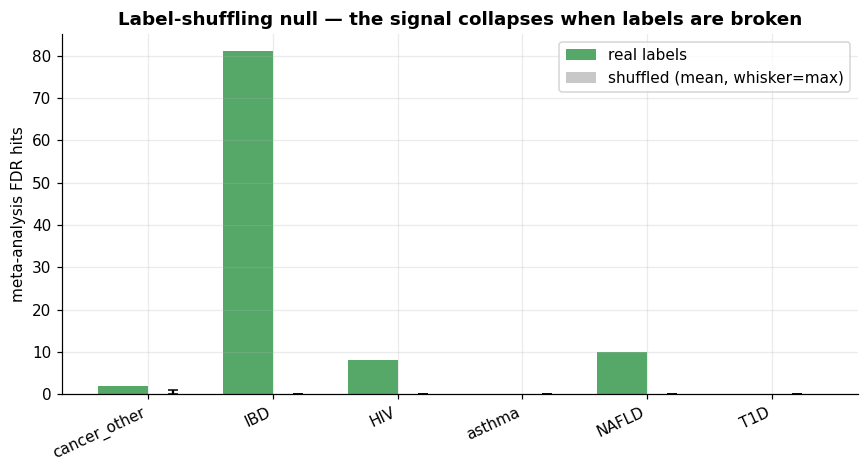

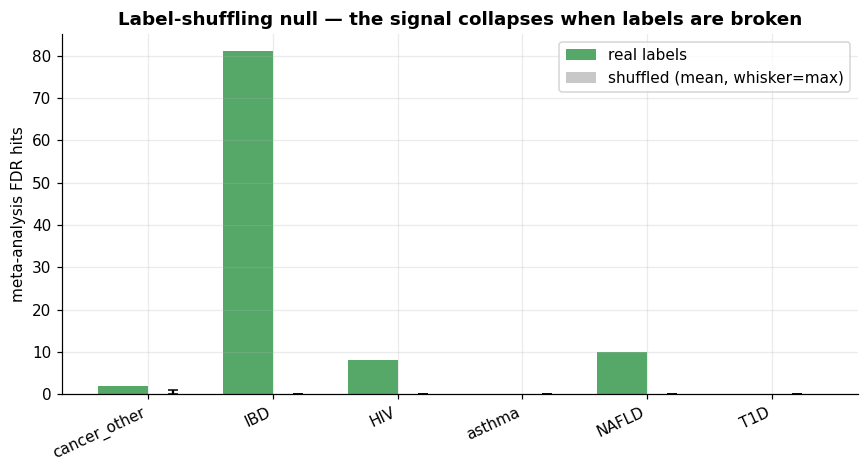

In [4]:
t0 = time.time()
null_df, real_hits = val.label_shuffle_null(
    clr_all, presence, frame, CATS, dcfg, TAXA,
    n_shuffles=vcfg["null_shuffles"], seed=SEED, progress=False)
null_df.to_csv(REPORTS / "validation_null.csv", index=False)
print(f"null: {vcfg['null_shuffles']} shuffles ({time.time() - t0:.0f}s)\n")

real_tot = real_hits[["meta_hits", "pooled_hits"]].sum()
nm = null_df.groupby("shuffle")["meta_hits"].sum()
npd = null_df.groupby("shuffle")["pooled_hits"].sum()
print("real labels    — meta FDR hits (Σ): "
      f"{int(real_tot['meta_hits'])}   pooled: {int(real_tot['pooled_hits'])}")
print(f"shuffled labels — meta hits per permutation: mean {nm.mean():.2f}, max {int(nm.max())}   "
      f"pooled: mean {npd.mean():.2f}, max {int(npd.max())}")
print("\nper-category (real vs shuffled mean):")
print(real_hits.merge(null_df.groupby("disease_category")[["meta_hits", "pooled_hits"]].mean()
                      .rename(columns=lambda c: c + "_null_mean").reset_index(),
                      on="disease_category")
      [["disease_category", "meta_hits", "meta_hits_null_mean", "pooled_hits", "pooled_hits_null_mean"]]
      .round(2).to_string(index=False))

fig = val.plot_null(null_df, real_hits)
fig.savefig(FIGURES / "phase6_null.png"); plt.close(fig)
fig = val.plot_null(null_df, real_hits); fig

## Step 2 — Depth-threshold sensitivity

The within-study cohort is rebuilt at 5,000 / 10,000 / 20,000 minimum reads (the same QC + cohort
logic), and the whole chain re-runs. Reported: replicated genera per category at each threshold,
and which replicated genera hold at *every* threshold vs only some.

depth sweep (14s)

replicated genera per category x threshold:
threshold         5000   10000  20000
disease_category                     
HIV                 7.0    8.0   21.0
IBD                78.0   76.0   78.0
NAFLD               8.0    8.0    0.0
T1D                 0.0    0.0    0.0
asthma              0.0    0.0    0.0
cancer_other        0.0    0.0    0.0

79 of 112 replicated genera hold at every threshold

threshold-specific replicated genera (not stable across all three):
disease_category                       genus  thresholds
             HIV       Tractidigestivibacter       20000
             HIV               Adlercreutzia       20000
             HIV              Incertae Sedis       20000
             HIV             Catenibacterium       20000
             HIV              Incertae Sedis 10000,20000
             HIV                Oribacterium       20000
             HIV [Ruminococcus] gnavus group       20000
             HIV                     UCG-009       2000

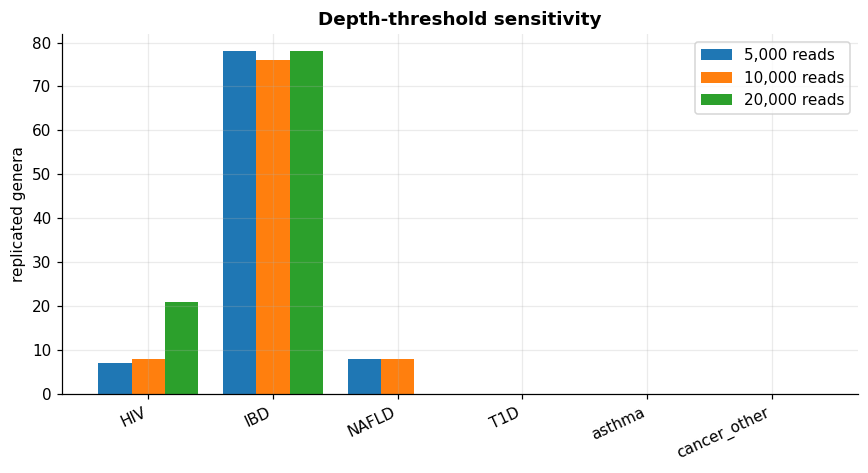

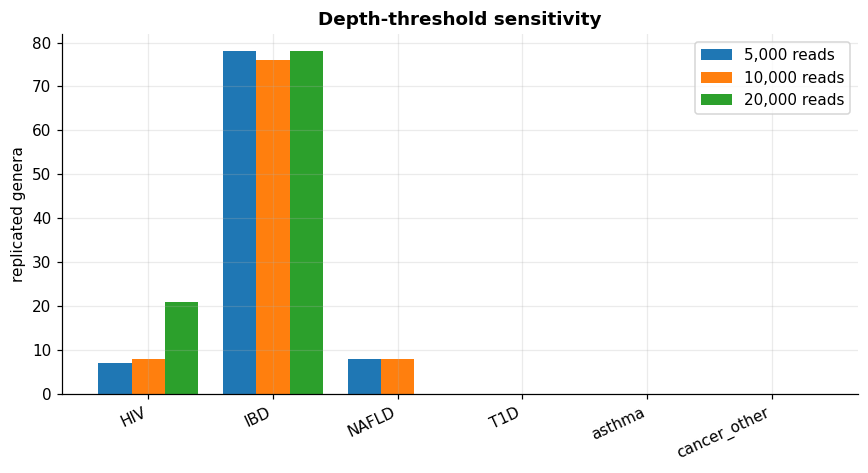

In [5]:
t0 = time.time()
depth_long, depth_stab = val.depth_threshold_sweep(
    harmonized, sample_depth, review_df, clr_all, presence,
    dcfg["category_groups"], CATS, dcfg, TAXA, vcfg["depth_thresholds"])
depth_stab.to_csv(REPORTS / "validation_depth_sensitivity.csv", index=False)
print(f"depth sweep ({time.time() - t0:.0f}s)\n")

print("replicated genera per category x threshold:")
print(depth_long.pivot_table(index="disease_category", columns="threshold",
                             values="n_replicated", fill_value=0).to_string())
n_stable = int(depth_stab["stable"].sum())
print(f"\n{n_stable} of {len(depth_stab)} replicated genera hold at every threshold")
print("\nthreshold-specific replicated genera (not stable across all three):")
print(depth_stab[~depth_stab["stable"]][["disease_category", "genus", "thresholds"]]
      .to_string(index=False) if (~depth_stab["stable"]).any() else "  (none)")

fig = val.plot_depth_sensitivity(depth_long)
fig.savefig(FIGURES / "phase6_depth_sensitivity.png"); plt.close(fig)
fig = val.plot_depth_sensitivity(depth_long); fig

## Step 3 — Transform sensitivity (CLR vs log-relative abundance)

Re-run with the taxon response as `log10` of relative abundance on the same closed
sub-composition (i.e. CLR without the centring step — the cleanest transform contrast), and
compare to the CLR result: meta-hit overlap and effect-size rank correlation per category.

In [6]:
t0 = time.time()
logrel = val.load_log_relative(INTERIM / "taxa_prev01.npz", set(frame["sample"]),
                               pseudocount=params["transform"]["clr_pseudocount"])
transform_df = val.transform_sensitivity(meta0, rep0, logrel, presence, frame, CATS, dcfg, TAXA)
transform_df.to_csv(REPORTS / "validation_transform_sensitivity.csv", index=False)
print(f"transform sensitivity ({time.time() - t0:.0f}s)\n")
print(transform_df.round(3).to_string(index=False))

transform sensitivity (4s)

   transform disease_category  meta_hits_clr  meta_hits_alt  meta_hits_shared  replicated_clr  replicated_alt  replicated_shared  effect_spearman
log_relative     cancer_other              2              1                 1               0               0                  0            0.992
log_relative              IBD             81             76                59              76              72                 56            0.992
log_relative              HIV              8             26                 7               8              20                  7            0.999
log_relative           asthma              0              0                 0               0               0                  0            0.995
log_relative            NAFLD             10              8                 8               8               5                  5            0.996
log_relative              T1D              0              0                 0               0   

## Step 4 — Prevalence-filter sensitivity

Re-run restricting the tested taxa to those present in ≥1% vs ≥10% of the *whole compendium*
(the ≥1% set is the full CLR matrix; ≥10% is a 151-genus subset of it).

prevalence sensitivity (7s)

prevalence_tier   0.01  0.10
disease_category            
HIV                8.0   8.0
IBD               76.0  75.0
NAFLD              8.0   7.0
T1D                0.0   0.0
asthma             0.0   0.0
cancer_other       0.0   0.0

taxa universe per tier: {0.01: 419, 0.1: 157}


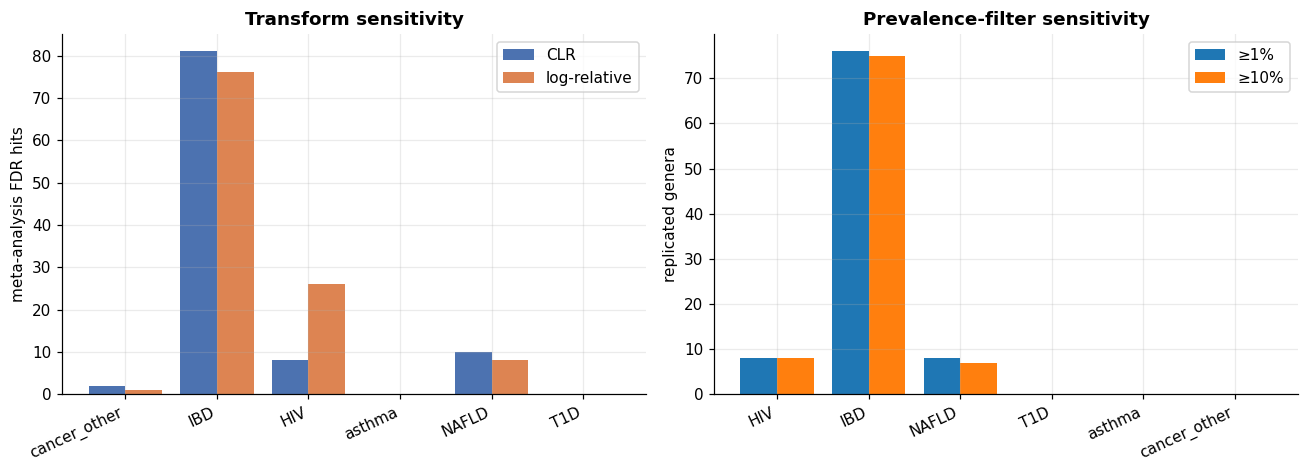

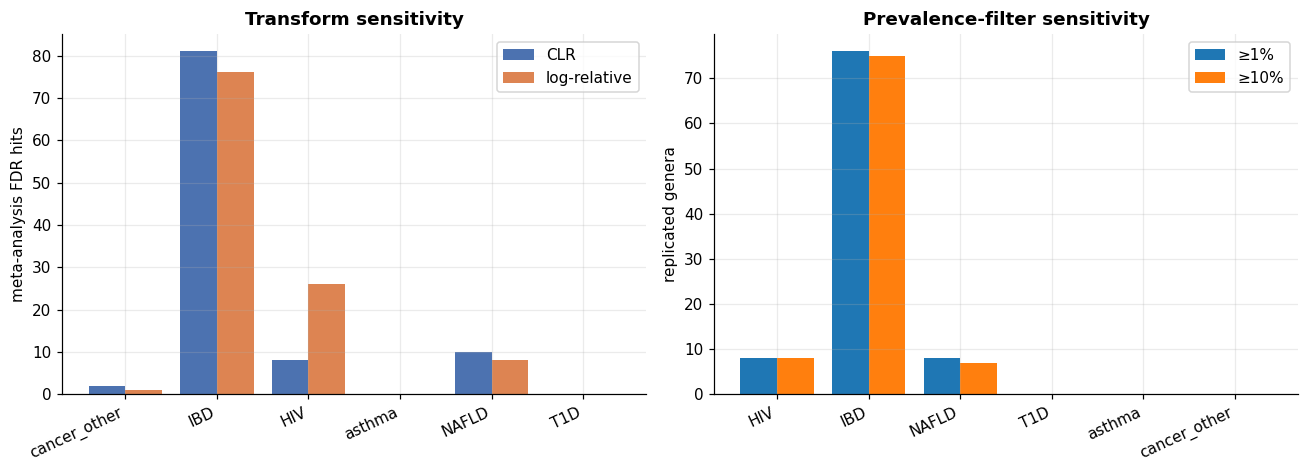

In [7]:
t0 = time.time()
prev_long, prev_taxa = val.prevalence_sensitivity(
    clr_all, presence, frame, CATS, dcfg, TAXA, vcfg["prevalence_tiers"])
prev_long.to_csv(REPORTS / "validation_prevalence_sensitivity.csv", index=False)
print(f"prevalence sensitivity ({time.time() - t0:.0f}s)\n")
print(prev_long.pivot_table(index="disease_category", columns="prevalence_tier",
                            values="n_replicated", fill_value=0).to_string())
print("\ntaxa universe per tier:",
      prev_long.groupby("prevalence_tier")["n_taxa_universe"].first().to_dict())

fig = val.plot_robustness(transform_df, prev_long)
fig.savefig(FIGURES / "phase6_robustness.png"); plt.close(fig)
fig = val.plot_robustness(transform_df, prev_long); fig

## Step 5 — Literature cross-check

Each category's replicated hits (top by meta q) vs the curated genus-direction priors in
`config/literature_priors.yaml`. `expected` up/down is a substring match of the genus against the
prior lists; `observed` is the sign of the meta-analysis effect. Placeholder genus names
(`UCG-005`, `Christensenellaceae R-7 group`, …) have no prior and are reported as such. The
source DOIs per category are emitted for a manual read.

In [8]:
per_hit, lit_rollup = val.literature_check(
    conc0, priors, projects_df, per_project0,
    top_n=vcfg["literature_top_n"], fdr_alpha=dcfg["fdr_alpha"])
per_hit.to_csv(REPORTS / "literature_crosscheck.csv", index=False)
print(lit_rollup[["disease_category", "n_checked", "concordant", "discordant", "no_prior"]]
      .to_string(index=False))

print("\nhits with a prior:")
withp = per_hit[per_hit["verdict"] != "no_prior"]
print(withp[["disease_category", "genus", "meta_effect", "meta_q", "expected", "observed", "verdict"]]
      .round(3).to_string(index=False) if len(withp) else "  (none)")

disease_category  n_checked  concordant  discordant  no_prior
             HIV          8           1           0         7
             IBD         25           8           0        17
           NAFLD          8           0           0         8

hits with a prior:
disease_category                            genus  meta_effect  meta_q expected observed    verdict
             HIV                    Fusobacterium        0.622   0.021       up       up concordant
             IBD  [Eubacterium] ruminantium group       -1.756   0.000     down     down concordant
             IBD               Peptostreptococcus        0.710   0.000       up       up concordant
             IBD                 Fusicatenibacter       -1.270   0.000     down     down concordant
             IBD                      Akkermansia       -1.384   0.000     down     down concordant
             IBD                        Alistipes       -1.119   0.000     down     down concordant
             IBD [Eubacterium] x

## Step 6 — Final report

`reports/final_report.md` — the stated limitations first, then the harmonisation coverage,
the cohort flow, the technical-variance answer, the disease-association result, and every
robustness check above.

In [9]:
report_md = val.final_report_md(
    REPORTS, elig, null_df, real_hits, depth_long, depth_stab,
    transform_df, prev_long, lit_rollup, fdr_alpha=dcfg["fdr_alpha"])
(REPORTS / "final_report.md").write_text(report_md, encoding="utf-8")
print(f"wrote reports/final_report.md ({len(report_md):,} chars)")
print("\n" + "\n".join(report_md.splitlines()[:40]))

wrote reports/final_report.md (10,726 chars)

# Human Microbiome Compendium — final report

## Limitations, stated up front

- **The sample is not the world.** ~61% of samples are from Europe and North America, 36% from the United States alone; ~17% have no usable country. Any claim about "the human gut microbiome" is really a claim about a mostly Western one.
- **Genus-level resolution only.** Broad bacterial groups, not species or strains. Strain-level effects are invisible here.
- **Observational, so no causal claims.** An elevated genus in a disease may be a consequence of the disease, its treatment, or an associated diet change.
- **Most samples have no health label.** ~81.5% are unlabelled; the disease work rests on the labelled minority, and the within-study comparison on 41 projects.
- **Health labels are self-defined by each study.** One study's "healthy" is another's "mild symptoms" -- the words are harmonised, the underlying clinical assessments are not.
- **Some labels are 

## Step 7 — Checks

- the shuffled-label null produces essentially no FDR hits
- the baseline replicated set matches what the differential-abundance step wrote
- every robustness table is populated for every eligible category

In [10]:
# baseline reproduces the differential-abundance step exactly
for c in CATS:
    assert rep0.get(c, set()) == prev_rep.get(c, set()), f"replicated set drifted for {c}"
print("PASS - baseline replicated set is identical to reports/concordance.csv")

# shuffled null collapses: mean meta hits per permutation is a tiny fraction of the real count
real_meta_total = int(real_hits["meta_hits"].sum())
null_meta_mean = null_df.groupby("shuffle")["meta_hits"].sum().mean()
assert null_meta_mean <= max(2.0, 0.05 * real_meta_total), \
    f"shuffled-label null still produces {null_meta_mean:.1f} meta hits/permutation (real: {real_meta_total})"
print(f"PASS - shuffled null: {null_meta_mean:.2f} meta hits/permutation vs {real_meta_total} on real labels")

# robustness tables cover every eligible category
for name, df in [("depth", depth_long), ("transform", transform_df), ("prevalence", prev_long)]:
    missing = set(CATS) - set(df["disease_category"])
    assert not missing, f"{name} sensitivity table missing categories: {missing}"
print("PASS - depth / transform / prevalence tables cover every eligible category")

assert (REPORTS / "final_report.md").exists()
print("PASS - final_report.md written")

PASS - baseline replicated set is identical to reports/concordance.csv
PASS - shuffled null: 0.10 meta hits/permutation vs 101 on real labels
PASS - depth / transform / prevalence tables cover every eligible category
PASS - final_report.md written


## Summary

In [11]:
for f in (sorted(REPORTS.glob("validation_*")) + sorted(REPORTS.glob("literature_*"))
          + [REPORTS / "final_report.md"] + sorted(FIGURES.glob("phase6_*"))):
    if f.exists():
        print(f"{str(f.relative_to(ROOT)):46s} {f.stat().st_size / 1e3:8.1f} KB")

reports\validation_depth_sensitivity.csv           13.9 KB
reports\validation_null.csv                         1.3 KB
reports\validation_prevalence_sensitivity.csv       0.3 KB
reports\validation_transform_sensitivity.csv        0.5 KB
reports\literature_crosscheck.csv                   6.8 KB
reports\final_report.md                            11.0 KB
reports\figures\phase6_depth_sensitivity.png       43.6 KB
reports\figures\phase6_null.png                    45.9 KB
reports\figures\phase6_robustness.png              56.7 KB


## Results and notes

### What this notebook produced

- `reports/validation_null.csv` — per (shuffle, category) FDR-hit counts under label permutation.
- `reports/validation_depth_sensitivity.csv` — each replicated genus and which of 5k / 10k / 20k
  it survives.
- `reports/validation_transform_sensitivity.csv` — CLR vs log-relative: hit overlap + effect ρ.
- `reports/validation_prevalence_sensitivity.csv` — replicated counts at the ≥1% vs ≥10%
  compendium-prevalence universe.
- `reports/literature_crosscheck.csv` — replicated hits vs curated genus-direction priors, with
  the source DOIs per category.
- `reports/final_report.md` — the assembled report, limitations first.
- `reports/figures/phase6_{null,depth_sensitivity,robustness}.png`.

### How to read it

- **The null is the load-bearing check.** If a shuffled-label run still returns FDR hits, the
  effect sizes and q-values from the real run cannot be trusted — a covariate or a
  degrees-of-freedom bug is inflating significance. Zero (or near-zero) hits here is what makes
  the real numbers meaningful.
- **A replicated genus that only survives at one depth threshold** is reported as
  threshold-specific, not as a finding. The genera that hold across 5k / 10k / 20k *and* across
  CLR vs log-relative *and* across the prevalence tiers are the ones to carry forward.
- **The literature check is orientation only.** The priors are textbook-level consensus, not
  claims read from these studies' papers; a `discordant` verdict means "read the source DOI",
  not "the analysis is wrong". Many top hits are placeholder genus names with no prior at all.

### Scope / caveats

- **Within-study cohort only**, as upstream — the full labelled catalogue (116 projects) still
  needs the remaining candidate label fields curated.
- **The pooled test uses ComBat+OLS throughout** these checks (the primary concordance method);
  the mixed-model variant is not re-run in every permutation for runtime.
- **The 5k / 20k CLR is recomputed here**, not read from `abund_clr.parquet` (which only holds
  the 10k population); the recipe is identical, and the 10k slice is asserted to match the
  differential-abundance step's replicated set.